# Comparer les stimulations optogénétiques d'une même souris à tous les âges
Ouvre automatiquement tous les dossiers `_StimOpto_Xmois` d'une même souris, calcule la moyenne de toutes les stimulations pour chaque âge, recale chaque courbe pour qu'elle vaille 0 pile à t=0 (pour bien voir la superposition), et affiche toutes les courbes sur un seul graphique (une couleur par âge, échelle Y ajustée aux courbes) avec la sélection manuelle (aire / pente) au clic, comme dans le 6E_3.

**Rien n'est enregistré automatiquement** — c'est uniquement une visualisation pour calcul manuel.

### Charger les packages

In [1]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os
import re
import json
from IPython.display import display, clear_output
from ipywidgets import Output
from ipyfilechooser import FileChooser
from scipy.stats import zscore
import matplotlib.cm as cm
from scipy.interpolate import interp1d
%matplotlib widget

### Charger les coordonnées LFP de toutes les souris

In [2]:
all_LFPcoordinates = pd.read_csv('_LFP_coordinates_of_all_mice.csv', sep=';', index_col=0)
all_LFPcoordinates = all_LFPcoordinates.astype(str)

### Choisir le dossier de la souris
Choisir le dossier **au niveau de la souris** (celui qui contient tous les sous-dossiers `..._StimOpto_3mois`, `..._StimOpto_4mois`, `..._StimOpto_5mois`, etc. pour CETTE souris).

In [3]:
try: # tries to retrieve dpath either from a previous run or from a previous notebook
    %store -r dpath
except:
    print("the path was not defined in store")
    dpath = "//10.69.168.1/crnldata/forgetting/"

fc1 = FileChooser(dpath, select_default=True, show_only_dirs=True,
                   title="<b>Aller dans le dossier de la souris (contenant tous les âges _StimOpto_Xmois)</b>")
display(fc1)

def update_my_folder(chooser):
    global dpath
    dpath = chooser.selected
    %store dpath
    return

fc1.register_callback(update_my_folder)

FileChooser(path='\\10.69.168.1\crnldata\forgetting\Carla\SleepRecordings\CarreMarron\7mois', filename='', tit…

### Paramètres d'analyse

In [14]:
halfdurEPSP = 0.1      # sec, fenêtre affichée autour de chaque stim
analyseWindow = 0.025  # sec post-stimulation, utilisée pour le rejet des outliers

# === ÂGE DE RÉFÉRENCE POUR LA NORMALISATION ===
reference_age_months = 4  # les AUC et pentes seront aussi exprimées en % de la valeur à cet âge


### Fonction d'analyse d'une LFP (identique au 6E_3 : moyenne globale + 1/3, 2/3, 3/3)

In [15]:
def analyze_single_lfp(lfp_signal, lfp_name, ttl_opto, lfp_timestamps, sample_rate, period_name=""):

    if len(ttl_opto) == 0:
        return None

    # Extraction des stimulations
    all_stim = []
    for ttl in ttl_opto:
        idx = (np.abs(lfp_timestamps - ttl)).argmin()
        stim_signal = lfp_signal[idx - round(halfdurEPSP * sample_rate):
                                   idx + round(halfdurEPSP * sample_rate)]
        all_stim.append(stim_signal)

    all_stim_df = pd.DataFrame(all_stim).T

    # Correction de baseline
    baseline_window = slice(0, int(halfdurEPSP * sample_rate))
    corrected_columns = []
    for col in all_stim_df.columns:
        baseline_mean = all_stim_df[col][baseline_window].mean()
        corrected_columns.append(all_stim_df[col] - baseline_mean)

    all_stim_corrected = pd.concat(corrected_columns, axis=1)
    all_stim_corrected.columns = all_stim_df.columns

    # Suppression outliers amplitude (>= 4xSD)
    amplitude_temp = []
    for col in all_stim_corrected.columns:
        post_stim_start = int(halfdurEPSP * sample_rate)
        post_stim_end = int((halfdurEPSP + analyseWindow) * sample_rate)
        post_stim_window = all_stim_corrected[col][post_stim_start:post_stim_end]
        amplitude = post_stim_window.max() - post_stim_window.min()
        amplitude_temp.append(amplitude)

    amp_array = np.array(amplitude_temp)
    amp_mean = np.mean(amp_array)
    amp_std = np.std(amp_array)
    valid_indices = np.where(amp_array < amp_mean + 4 * amp_std)[0]
    all_stim_corrected = all_stim_corrected.iloc[:, valid_indices]
    nb_stims_valid = len(valid_indices)

    # Calcul de la moyenne
    mean_signal = all_stim_corrected.mean(axis=1)
    std_signal = all_stim_corrected.std(axis=1)
    time_axis = np.linspace(-halfdurEPSP * 1000, halfdurEPSP * 1000,
                            all_stim_corrected.shape[0])

    # Recalage explicite : on force la valeur au temps 0 (interpolée) à 0.
    # La correction de baseline ci-dessus centre déjà le signal sur ~0 avant la stim,
    # ce recalage garantit que TOUTES les courbes partent exactement de 0 pile à t=0,
    # ce qui permet de bien voir si elles se superposent ou non juste après la stim.
    interp_t0 = interp1d(time_axis, mean_signal, kind='linear', bounds_error=False, fill_value='extrapolate')
    offset_t0 = float(interp_t0(0))
    mean_signal = mean_signal - offset_t0

    results = {
        'LFP': lfp_name,
        'Period': period_name,
        'Nb_stimulations': nb_stims_valid,
        'mean_signal': mean_signal,
        'std_signal': std_signal,
        'time_axis': time_axis
    }

    return results

### Parcourir tous les dossiers `_StimOpto_Xmois` de la souris et charger les données brutes par âge
Convertit les `.dat` en `.pkl` si nécessaire (comme le 6E_6), puis charge chaque enregistrement et identifie la souris et **toutes** les régions disponibles (données brutes gardées en mémoire). Le choix de la région à analyser/comparer se fait dans la **dernière cellule**, pour pouvoir en changer sans avoir à relancer ce chargement.

In [16]:
folder_base = Path(dpath)

print("Transformation des .dat en .pkl si nécessaire...")
for root, dirs, files in os.walk(folder_base):
    datfiles = [f for f in files if f.endswith('.dat')]
    for datfile in datfiles:
        if 'StimOpto' in str(root):  # ne traite que les dossiers de stim opto
            datfilepath = Path(os.path.normpath(os.path.join(root, datfile)))
            pklpath = Path(f'{datfilepath.parent}\\DataFrame_rawdataDS.pkl')
            if not pklpath.exists():
                print(f'.dat file found = {datfilepath}')
                DataRec = np.fromfile(datfilepath, dtype="int16")
                Metadatafilepath = Path(os.path.join(datfilepath.parent.parent.parent, 'structure.oebin'))
                with open(Metadatafilepath) as f:
                    metadata = json.load(f)
                samplerate = metadata['continuous'][0]['sample_rate']
                numchannel = metadata['continuous'][0]['num_channels']
                rec_ch_list = np.array([int(''.join(filter(str.isdigit, c['channel_name']))) - 1
                                         for c in metadata['continuous'][0]['channels'] if c['channel_name'].startswith('CH')])
                DataRec = DataRec.reshape(-1, numchannel)
                numchannel = len(rec_ch_list)
                DataRec = DataRec[:, :numchannel]

                LFPtimestamps = None
                for file_pathTS in datfilepath.parent.parent.parent.glob('**/continuous/*/timeStamps.npy'):
                    LFPtimestamps = np.load(file_pathTS)
                LFPs_df = pd.DataFrame(DataRec, columns=rec_ch_list)

                if samplerate > 1000:
                    new_sampling_rate = 1000
                    Nmber_points = int(np.shape(LFPs_df)[0] * new_sampling_rate / samplerate)
                    LFPs_df_DS = pd.DataFrame(signal.resample(LFPs_df, Nmber_points, axis=0), columns=LFPs_df.columns.values)
                    LFPtimestampsDS = LFPtimestamps[::int(samplerate / new_sampling_rate)][:-1]
                    LFPs_df_DS.to_pickle(f'{datfilepath.parent}/DataFrame_rawdataDS.pkl')
                    np.save(f'{file_pathTS.parent}/timeStampsDS.npy', LFPtimestampsDS)
                else:
                    LFPs_df.to_pickle(f'{datfilepath.parent}/DataFrame_rawdataDS.pkl')
                    np.save(f'{file_pathTS.parent}/timeStampsDS.npy', LFPtimestamps)
print("... terminé.\n")

results_by_age = {}   # gardé pour compatibilité, non utilisé directement ici
raw_data_by_age = {}  # {age: {'mouse':, 'stim_duration':, 'LFPs_df':, 'TTL_Opto':, 'LFPtimestamps':, 'samplerate':, 'RecordedArea':, 'ChoosenChannels':}}
mouse_found = None

print("Chargement des enregistrements par âge (toutes régions — le choix de la région se fait dans la dernière cellule)...")
for root, dirs, files in os.walk(folder_base):
    potentialLFPfiles = [f for f in files if f.endswith('DataFrame_rawdataDS.pkl')]
    for LFPfilename in potentialLFPfiles:
        if 'StimOpto' in str(root):
            LFPfilepath = Path(os.path.normpath(os.path.join(root, LFPfilename)))
            print('#####################################################')
            print(f'.pkl file found = {LFPfilepath}')

            LFPs_df = pd.read_pickle(LFPfilepath)
            samplerate = 1000
            rec_ch_list = LFPs_df.columns.values

            LFPtimestamps = None
            for file_pathTS in LFPfilepath.parent.glob('**/timeStampsDS.npy'):
                LFPtimestamps = np.load(file_pathTS)
            if LFPtimestamps is None:
                print('⚠️ pas de timestamps trouvés, dossier ignoré')
                continue

            # Charger les TTL
            TTL_Opto_duration = []
            TTL_Opto = np.array([])
            for file_pathTTL in LFPfilepath.parent.parent.parent.glob('**/TTL/timeStamps.npy'):
                TTL_Opto_o = np.load(file_pathTTL)
                TTL_Opto_duration = [round(TTL_Opto_o[i + 1] - TTL_Opto_o[i], 4) for i in range(len(TTL_Opto_o) - 1)[::2]]
                TTL_Opto = TTL_Opto_o[::2]

            if len(TTL_Opto_duration) == 0:
                print('⚠️ pas de stim opto trouvées, dossier ignoré')
                continue

            # Identifier la souris à partir du chemin
            mouse = []
            pos_mice = []
            for mouse_name in all_LFPcoordinates.index:
                if mouse_name in str(LFPfilepath):
                    mouse.append(mouse_name)
                    pos_mice.append(str(LFPfilepath).find(mouse_name))
            mouse = [x for _, x in sorted(zip(pos_mice, mouse))]

            if len(mouse) == 0:
                print("⚠️ Nom de souris non trouvé dans le chemin, dossier ignoré")
                continue
            ID = 0
            mouse = mouse[0]
            if mouse_found is None:
                mouse_found = mouse
            elif mouse != mouse_found:
                print(f"⚠️ Souris différente trouvée ({mouse}) dans le dossier choisi, dossier ignoré")
                continue

            # Extraire l'âge depuis le nom du dossier (ex: ..._StimOpto_4mois...)
            age_match = re.search(r'StimOpto_([A-Za-z0-9]+)', str(LFPfilepath))
            age = age_match.group(1) if age_match else LFPfilepath.parents[4].name

            # Identifier les canaux LFP de la souris
            for region in all_LFPcoordinates.loc[mouse].index:
                locals()[f'{region}_0'] = []
                locals()[f'{region}_1'] = []
                locals()[f'{region}_0ch'] = []
                locals()[f'{region}_1ch'] = []

            RecordedArea = []
            ChoosenChannels = []
            combined = []
            rec_ch_list_mouse = [value for value in rec_ch_list if 0 + (ID * 32) <= value <= 31 + (ID * 32)]
            for rec_ch in rec_ch_list_mouse:
                for idx, LFPcoord_str in enumerate(all_LFPcoordinates.loc[mouse]):
                    region = all_LFPcoordinates.loc[mouse].index[idx]
                    if LFPcoord_str != 'nan' and region != 'EMG':
                        LFPcoord = LFPcoord_str.split('_')[:2]
                        num_ch = np.where(str(rec_ch - (ID * 32)) == np.array(LFPcoord))[0]
                        if len(num_ch) > 0:
                            LFP = locals()[f'{region}_0']
                            if len(LFP) > 0:
                                locals()[f'{region}_1'] = np.array(LFPs_df[(rec_ch)])
                                locals()[f'{region}_1ch'] = rec_ch
                            else:
                                locals()[f'{region}_0'] = np.array(LFPs_df[(rec_ch)])
                                locals()[f'{region}_0ch'] = rec_ch
                            break
                        continue

            for region in all_LFPcoordinates.loc[mouse].index:
                for n in range(0, 2, 1):
                    LFP = locals()[f'{region}_{n}']
                    LFP_ch = locals()[f'{region}_{n}ch']
                    if len(LFP) > 0:
                        RecordedArea.append(f'{region}_{n}')
                        ChoosenChannels.append(LFP_ch)

            if len(RecordedArea) == 0:
                print("⚠️ Aucune région identifiée pour cet enregistrement, dossier ignoré")
                continue

            stim_duration = np.unique(TTL_Opto_duration)[0] * 1000  # ms

            raw_data_by_age[age] = {
                'mouse': mouse,
                'stim_duration': stim_duration,
                'LFPs_df': LFPs_df,
                'TTL_Opto': TTL_Opto,
                'LFPtimestamps': LFPtimestamps,
                'samplerate': samplerate,
                'RecordedArea': RecordedArea,
                'ChoosenChannels': ChoosenChannels,
            }
            print(f"  -> Age {age} : régions disponibles = {RecordedArea}")

print(f"\n✓ {len(raw_data_by_age)} âge(s) chargé(s) pour la souris {mouse_found} (données brutes, toutes régions).")
print("ℹ️  Choisis 'Selected_region' directement dans la dernière cellule, puis relance uniquement celle-ci.")

Transformation des .dat en .pkl si nécessaire...
.dat file found = \\10.69.168.1\crnldata\forgetting\Carla\OpenEphysData\Opto_stim\RH\APPPS1\Male\EtoileBleu\EtoileBleu_2026-08-11_15-20-15_StimOpto_4mois\Record Node 101\experiment1\recording1\continuous\OE_FPGA_Acquisition_Board-100.Rhythm Data\continuous.dat
... terminé.

Chargement des enregistrements par âge (toutes régions — le choix de la région se fait dans la dernière cellule)...
#####################################################
.pkl file found = \\10.69.168.1\crnldata\forgetting\Carla\OpenEphysData\Opto_stim\RH\APPPS1\Male\EtoileBleu\EtoileBleu_2026-07-20_15-18-48_StimOpto_3mois\Record Node 101\experiment1\recording1\continuous\OE_FPGA_Acquisition_Board-100.Rhythm Data\DataFrame_rawdataDS.pkl
  -> Age 3mois : régions disponibles = ['S1_0', 'S1_1', 'PFC_0', 'PFC_1', 'CA1_0', 'CA1_1', 'oPFC_0', 'oPFC_1', 'EnthC_0', 'EnthC_1', 'RH_0', 'RH_1']
#####################################################
.pkl file found = \\10.69.168.1\

### Visualisation comparative : une couleur par âge
**C'est ici que tu choisis la région (`Selected_region`)** — modifie-la et relance uniquement cette cellule, pas besoin de recharger les données. Une seule courbe par âge (moyenne de toutes les stimulations), recalée pour valoir 0 pile à t=0 pour bien voir si les courbes se superposent. Cliquez sur 2 points (n'importe où sur le graphique, juste pour vous positionner précisément) → l'AUC est calculée pour **toutes** les courbes entre ces 2 mêmes points. Double-cliquez sur 2 points → la pente est calculée pour **toutes** les courbes entre ces 2 mêmes points.

In [29]:
Selected_region = 'S1_1' 

  -> Age 3mois : 111 stim valides
  -> Age 4mois : 117 stim valides

✓ 2 âge(s) disponibles pour la région S1_1 : ['3mois', '4mois']
💡 Cliquez sur 2 points (n'importe où sur le graphique, peu importe la courbe visée) pour calculer l'AUC de TOUTES les courbes entre ces 2 mêmes points.
   Double-cliquez sur 2 points pour calculer la PENTE de TOUTES les courbes entre ces 2 mêmes points.
   Un 3ème clic (ou double-clic) réinitialise la sélection en cours.



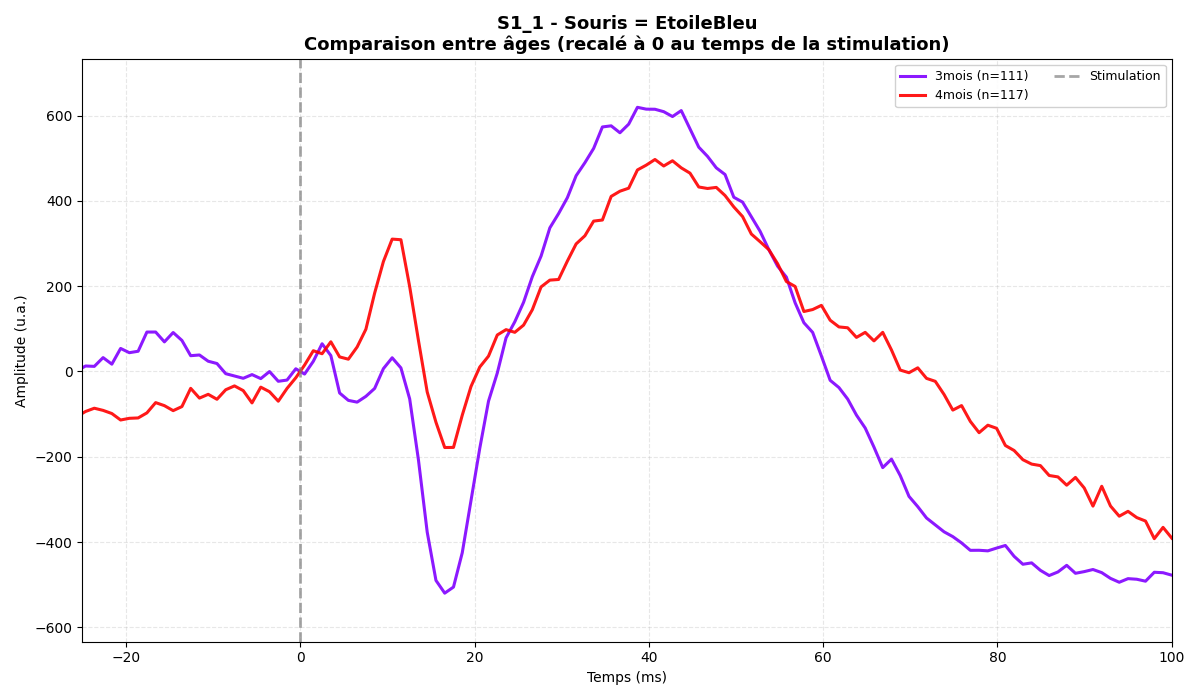

✓ Graphique affiché : S1_1, souris EtoileBleu, âges ['3mois', '4mois']
ℹ️  Résultats accessibles dans les dictionnaires 'auc_results' et 'slope_results' (clé = âge).


Age,x1_ms,x2_ms,AUC,AUC_abs,Nb_stims,AUC_norm_4mois
3mois,2.571495,5.557694,-209.602340,209.602340,111,-23.518096
4mois,2.571495,5.557694,8.912386,35.733641,117,1.000000


Age,xa_ms,xb_ms,Slope_per_ms,Nb_stims,Slope_norm_4mois
3mois,6.221294,10.231745,23.590188,111,0.3861
4mois,6.221294,10.231745,61.098622,117,1.0000


In [ ]:
plt.close('all')

def age_sort_key(age):
    m = re.search(r'\d+', age)
    return int(m.group()) if m else 0

def build_results_by_age(region):
    """Calcule results_by_age pour la région choisie, à partir des données brutes déjà chargées (raw_data_by_age)."""
    results = {}
    for age, raw in raw_data_by_age.items():
        if region not in raw['RecordedArea']:
            print(f"⚠️ Région {region} non trouvée pour l'âge {age} ({raw['RecordedArea']}), âge ignoré")
            continue
        SelectedLFP = np.array(raw['LFPs_df'][raw['ChoosenChannels'][raw['RecordedArea'].index(region)]])
        result_all = analyze_single_lfp(SelectedLFP, region, raw['TTL_Opto'], raw['LFPtimestamps'], raw['samplerate'], period_name="Toutes")
        if result_all is None:
            continue
        results[age] = {'mouse': raw['mouse'], 'stim_duration': raw['stim_duration'], 'results': [result_all]}
        print(f"  -> Age {age} : {result_all['Nb_stimulations']} stim valides")
    return results

results_by_age = build_results_by_age(Selected_region)
print(f"\n✓ {len(results_by_age)} âge(s) disponibles pour la région {Selected_region} : {sorted(results_by_age.keys())}")

ages_sorted = sorted(results_by_age.keys(), key=age_sort_key)
age_colors = dict(zip(ages_sorted, cm.rainbow(np.linspace(0, 1, len(ages_sorted)))))

# --- Préparation des courbes disponibles (une par âge, "Toutes" uniquement) ---
curves_data = {}
for age in ages_sorted:
    res = results_by_age[age]['results'][0]  # une seule entrée : "Toutes"
    name = age
    t_axis = np.array(res['time_axis'])
    m_signal = np.array(res['mean_signal'])
    curves_data[name] = {
        'time_axis': t_axis,
        'mean_signal': m_signal,
        'std_signal': np.array(res['std_signal']),
        'color': age_colors[age],
        'nb_stims': res['Nb_stimulations'],
        'age': age,
        'period': res['Period'],
        'interp': interp1d(t_axis, m_signal, kind='linear', bounds_error=False, fill_value=np.nan)
    }

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111)

# fenêtre d'affichage utilisée pour cadrer l'échelle Y sur les courbes réellement visibles
xlim_display = (-25, 100)

for name, cd in curves_data.items():
    ax.plot(cd['time_axis'], cd['mean_signal'],
            color=cd['color'], linewidth=2.2, alpha=0.9,
            label=f"{cd['age']} (n={cd['nb_stims']})")

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Stimulation')
ax.set(xlabel="Temps (ms)", ylabel="Amplitude (u.a.)", xlim=xlim_display)
ax.set_title(f"{Selected_region} - Souris = {mouse_found}\nComparaison entre âges (recalé à 0 au temps de la stimulation)",
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, ncols=2)
ax.grid(True, alpha=0.3, linestyle='--')

# --- Échelle Y ajustée aux courbes affichées dans la fenêtre xlim_display (pas au SEM) ---
y_visible = []
for cd in curves_data.values():
    mask = (cd['time_axis'] >= xlim_display[0]) & (cd['time_axis'] <= xlim_display[1])
    if mask.any():
        y_visible.append(cd['mean_signal'][mask])
if y_visible:
    y_all = np.concatenate(y_visible)
    y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)
    y_margin = 0.1 * (y_max - y_min) if y_max > y_min else 1
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

print("💡 Cliquez sur 2 points (n'importe où sur le graphique, peu importe la courbe visée) pour calculer l'AUC de TOUTES les courbes entre ces 2 mêmes points.")
print("   Double-cliquez sur 2 points pour calculer la PENTE de TOUTES les courbes entre ces 2 mêmes points.")
print("   Un 3ème clic (ou double-clic) réinitialise la sélection en cours.\n")

click_state = {'points': [], 'artists': []}   # sélection en cours pour l'aire
slope_state = {'points': [], 'artists': []}   # sélection en cours pour la pente

from IPython.display import display, HTML

auc_results = {}     # résultats AUC par courbe (clé = âge) — uniquement le DERNIER calcul
slope_results = {}   # résultats pente par courbe (clé = âge) — uniquement le DERNIER calcul

_table_handles = {'auc': None, 'slope': None}   # permet de remplacer le tableau affiché au lieu de l'empiler

def _show_table(key, header, df):
    html = HTML(f"<b>{header}</b>" + df.to_html(index=False))
    if _table_handles[key] is None:
        _table_handles[key] = display(html, display_id=True)
    else:
        _table_handles[key].update(html)


def compute_area_all(x1, x2, first_x):
    auc_results.clear()
    rows = []
    for name, cd in curves_data.items():
        interp_fn = cd['interp']
        color = cd['color']

        y_ref = float(interp_fn(first_x))
        x_fine = np.linspace(x1, x2, 500)
        y_fine = interp_fn(x_fine)
        baseline_fine = np.full_like(x_fine, y_ref)

        auc = np.trapz(y_fine - baseline_fine, x_fine)
        auc_abs = np.trapz(np.abs(y_fine - baseline_fine), x_fine)

        fill = ax.fill_between(x_fine, y_fine, baseline_fine, color=color, alpha=0.3)
        click_state['artists'].append(fill)

        auc_results[name] = {'x1': x1, 'x2': x2, 'auc': auc, 'auc_abs': auc_abs}
        rows.append({'Age': cd['age'], 'x1_ms': x1, 'x2_ms': x2, 'AUC': auc, 'AUC_abs': auc_abs, 'Nb_stims': cd['nb_stims']})

    # --- Normalisation par rapport à l'âge de référence (ex : 4 mois = 1) ---
    ref_name = next((n for n, c in curves_data.items() if age_sort_key(c['age']) == reference_age_months), None)
    if ref_name is not None:
        ref_auc = auc_results[ref_name]['auc']
        for row in rows:
            row[f'AUC_norm_{reference_age_months}mois'] = (row['AUC'] / ref_auc) if ref_auc != 0 else np.nan
            auc_results[row['Age']]['auc_norm'] = row[f'AUC_norm_{reference_age_months}mois']
    else:
        print(f"⚠️ Pas de courbe trouvée à {reference_age_months} mois : normalisation impossible.")

    df = pd.DataFrame(rows).sort_values('Age', key=lambda s: s.map(age_sort_key)).reset_index(drop=True)
    _show_table('auc', f"📐 Aire entre {x1:.2f} ms et {x2:.2f} ms — calculée pour toutes les courbes :", df)
    fig.canvas.draw_idle()


def compute_slope_all(xa, xb):
    slope_results.clear()
    xa, xb = sorted([xa, xb])
    rows = []
    for name, cd in curves_data.items():
        interp_fn = cd['interp']
        color = cd['color']

        ya, yb = float(interp_fn(xa)), float(interp_fn(xb))
        slope = (yb - ya) / (xb - xa)

        line, = ax.plot([xa, xb], [ya, yb], color=color, linewidth=3, marker='o',
                         markersize=6, zorder=6, alpha=0.95)
        slope_state['artists'].append(line)

        slope_results[name] = {'xa': xa, 'xb': xb, 'slope': slope}
        rows.append({'Age': cd['age'], 'xa_ms': xa, 'xb_ms': xb, 'Slope_per_ms': slope, 'Nb_stims': cd['nb_stims']})

    # --- Normalisation par rapport à l'âge de référence (ex : 4 mois = 1) ---
    ref_name = next((n for n, c in curves_data.items() if age_sort_key(c['age']) == reference_age_months), None)
    if ref_name is not None:
        ref_slope = slope_results[ref_name]['slope']
        for row in rows:
            row[f'Slope_norm_{reference_age_months}mois'] = (row['Slope_per_ms'] / ref_slope) if ref_slope != 0 else np.nan
            slope_results[row['Age']]['slope_norm'] = row[f'Slope_norm_{reference_age_months}mois']
    else:
        print(f"⚠️ Pas de courbe trouvée à {reference_age_months} mois : normalisation impossible.")

    df = pd.DataFrame(rows).sort_values('Age', key=lambda s: s.map(age_sort_key)).reset_index(drop=True)
    _show_table('slope', f"📈 Pente entre {xa:.2f} ms et {xb:.2f} ms — calculée pour toutes les courbes :", df)
    fig.canvas.draw_idle()


def reset_area():
    for artist in click_state['artists']:
        artist.remove()
    click_state['points'].clear()
    click_state['artists'].clear()
    auc_results.clear()
    _show_table('auc', "Aucune sélection d'aire en cours", pd.DataFrame())
    print("🔄 Sélection d'aire réinitialisée — cliquez sur 2 nouveaux points")


def reset_slope():
    for artist in slope_state['artists']:
        artist.remove()
    slope_state['points'].clear()
    slope_state['artists'].clear()
    slope_results.clear()
    _show_table('slope', "Aucune sélection de pente en cours", pd.DataFrame())
    print("🔄 Sélection de pente réinitialisée — double-cliquez sur 2 nouveaux points")


import time
_click_guard = {'sig': None, 't': 0.0}   # anti-doublon : ignore les clics quasi identiques déclenchés en rafale

def on_click(event):
    if event.inaxes != ax or event.button != 1:
        return
    if event.xdata is None:
        return

    xlim = ax.get_xlim()
    x = float(np.clip(event.xdata, xlim[0], xlim[1]))

    # --- Anti-doublon : si le même clic (même position, même type) revient dans les 0.3s, on l'ignore ---
    now = time.time()
    sig = (round(x, 6), bool(event.dblclick))
    if _click_guard['sig'] == sig and (now - _click_guard['t']) < 0.3:
        return
    _click_guard['sig'], _click_guard['t'] = sig, now

    if event.dblclick:
        # Un double-clic génère aussi un clic simple juste avant : on l'annule
        if click_state['points']:
            click_state['points'].pop()
            click_state['artists'].pop().remove()

        if len(slope_state['points']) >= 2:
            reset_slope()
            fig.canvas.draw_idle()
            return

        slope_state['points'].append(x)
        vl = ax.axvline(x=x, color='black', linestyle=':', linewidth=2, alpha=0.6)
        slope_state['artists'].append(vl)
        print(f"📍 Point pente {len(slope_state['points'])}: {x:.2f} ms")

        if len(slope_state['points']) == 2:
            compute_slope_all(slope_state['points'][0], slope_state['points'][1])

        fig.canvas.draw_idle()
        return

    # --- clic simple : aire ---
    if len(click_state['points']) >= 2:
        reset_area()
        fig.canvas.draw_idle()
        return

    click_state['points'].append(x)
    vl = ax.axvline(x=x, color='gray', linestyle=':', linewidth=1.2, alpha=0.5)
    click_state['artists'].append(vl)
    print(f"📍 Point aire {len(click_state['points'])}: {x:.2f} ms")

    if len(click_state['points']) == 2:
        x1, x2 = sorted(click_state['points'])
        if x2 - x1 < 1e-6:
            print("⚠️ Les 2 points sont trop proches, réessayez.")
        else:
            compute_area_all(x1, x2, click_state['points'][0])

    fig.canvas.draw_idle()


fig.canvas.mpl_connect('button_press_event', on_click)
plt.tight_layout()
plt.show()

print(f"✓ Graphique affiché : {Selected_region}, souris {mouse_found}, âges {ages_sorted}")
print("ℹ️  Résultats accessibles dans les dictionnaires 'auc_results' et 'slope_results' (clé = âge).")